In [1]:
import re

import numpy as np

log_file = "logs/anysleep_dodo_vs_dodh_sfs.log"
# srs = [1, 2, 4, 8, 16, 32, 64, 128, 256, 384, 640, 960, 1920, 3840]
srs = [1, 256]
n_classes = 5
possible_triplets = [f"{i}{j}{k}"
                     for i in range(n_classes)
                     for j in range(n_classes)
                     for k in range(n_classes)
                     if i != j and j != k]

# {model: {sr: {n_exp: {n_feat: {feat: score}}}}}
score_dict = {}
cur_model = None
cur_sr = 1
cur_exp = 0

with open(log_file, "r") as f:
    for line in f:
        if "Model epoch" in line:
            cur_model = line.strip().split(" ")[-1]
            score_dict[cur_model] = {cur_sr: {cur_exp: {}}}
        elif "Previous features" in line:
            arrs = re.findall(r"\[(.*?)\]", line)
            prev_feat = [int(x) for x in arrs[1].split(",") if x != ""]
            rem_feat = [int(x) for x in arrs[2].split(",")]
            scores = [float(x.replace("'", "")) for x in arrs[3].split(",")]
            chosen_feat = int(line.strip().split(" ")[-1])

            n_feat = len(prev_feat)
            if n_feat not in score_dict[cur_model][cur_sr][cur_exp]:
                score_dict[cur_model][cur_sr][cur_exp][n_feat] = {}

            for f, s in zip(rem_feat, scores):
                if f == chosen_feat:
                    score_dict[cur_model][cur_sr][cur_exp][n_feat][f"x{f}"] = s
                else:
                    score_dict[cur_model][cur_sr][cur_exp][n_feat][str(f)] = s

            if n_feat == 4:
                cur_exp += 1
                if cur_exp < 50:
                    score_dict[cur_model][cur_sr][cur_exp] = {}
        elif "sleep stages per epoch" in line:
            old_sr = int(line.split(" ")[4])
            if old_sr == srs[-1]:
                cur_sr = 1
            else:
                cur_sr = srs[srs.index(old_sr) + 1]
                score_dict[cur_model][cur_sr] = {0: {}}
            cur_exp = 0

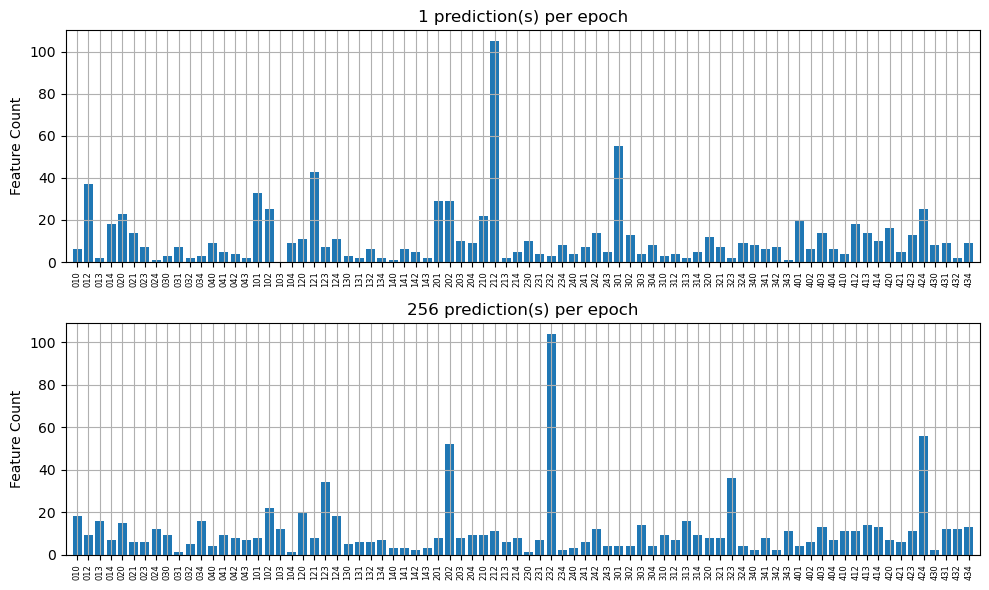

['212' '301']
['202' '232' '424']


In [10]:
from matplotlib import pyplot as plt

# matrix sr vs. which 5 features were chosen
mat_to_plot = np.zeros((len(possible_triplets), len(srs)))
for _, sd_mr in score_dict.items():
    for sr, sd_sr in sd_mr.items():
        sr_idx = srs.index(sr)
        for i_exp, sd_exp in sd_sr.items():
            if len(sd_exp) < 5:
                print("incomplete row", sr, i_exp, sd_exp.keys())
                continue
            chosen_feat = set([str(i) for i in range(80)]) - set(sd_exp[4].keys())
            chosen_feat_5 = [k for k in sd_exp[4].keys() if k.startswith("x")][0]
            for feat in chosen_feat:
                mat_to_plot[int(feat), sr_idx] += 1
            mat_to_plot[int(chosen_feat_5[1:]), sr_idx] += 1

_, axes = plt.subplots(len(srs), 1, figsize=(10, 6))
axes = axes.flatten()
for i_sr, sr in enumerate(srs):
    axes[i_sr].bar(range(len(possible_triplets)), mat_to_plot[:, i_sr], width=0.8)
    axes[i_sr].set_title(f"{sr} prediction(s) per epoch")
    axes[i_sr].set_ylabel("Feature Count")
    axes[i_sr].set_xticks(range(len(possible_triplets)), possible_triplets, rotation=90, fontsize=6)
    axes[i_sr].grid(True)
    axes[i_sr].set_xlim(-1, len(possible_triplets))

plt.tight_layout()
plt.show()

print(np.array(possible_triplets)[np.where(mat_to_plot[:, 0] > 50)[0]])
print(np.array(possible_triplets)[np.where(mat_to_plot[:, 1] > 50)[0]])